In [1]:
!pip install pandas numpy scikit_learn matplotlib
!pip install gradio

In [2]:
import pandas as pd
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [3]:
nltk.download('punkt')
nltk.download('punkt_tab')   
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\New\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\New\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\New\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\New\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [5]:
df = pd.read_csv(r"C:\Users\New\OneDrive\Desktop\my work\New folder (3)\sentment analysis\Twitter_Data.csv")
df.rename(columns={"clean_text": "text", "category": "sentiment"}, inplace=True)
df.head()

,text,sentiment
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [6]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = "".join([c for c in text if c not in string.punctuation])
    words = word_tokenize(text)
    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words]
    return " ".join(words)

df["cleaned"] = df["text"].astype(str).apply(clean_text)
df.head()

,text,sentiment,cleaned
0,when modi promised “minimum government maximum...,-1.0,modi promised “ minimum government maximum gov...
1,talk all the nonsense and continue all the dra...,0.0,talk nonsense continue drama vote modi
2,what did just say vote for modi welcome bjp t...,1.0,say vote modi welcome bjp told rahul main camp...
3,asking his supporters prefix chowkidar their n...,1.0,asking supporter prefix chowkidar name modi gr...
4,answer who among these the most powerful world...,1.0,answer among powerful world leader today trump...


In [7]:
df = df.dropna(subset=["sentiment"])
df["sentiment"] = df["sentiment"].astype(int)

In [8]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["cleaned"])
y = df["sentiment"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [10]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8761466482589354

Classification Report:

              precision    recall  f1-score   support

          -1       0.87      0.75      0.80      7230
           0       0.84      0.96      0.89     10961
           1       0.91      0.88      0.90     14404

    accuracy                           0.88     32595
   macro avg       0.87      0.86      0.86     32595
weighted avg       0.88      0.88      0.87     32595



In [11]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report Naive Bayes:\n")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.5751495628163829

Classification Report Naive Bayes:

              precision    recall  f1-score   support

          -1       0.93      0.12      0.21      7230
           0       0.87      0.35      0.50     10961
           1       0.52      0.98      0.68     14404

    accuracy                           0.58     32595
   macro avg       0.77      0.48      0.46     32595
weighted avg       0.73      0.58      0.51     32595



In [12]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
svm_model = LinearSVC(dual="auto", random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report SVM:\n")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.8896763307255714

Classification Report SVM:

              precision    recall  f1-score   support

          -1       0.87      0.79      0.83      7230
           0       0.87      0.95      0.91     10961
           1       0.92      0.89      0.90     14404

    accuracy                           0.89     32595
   macro avg       0.89      0.88      0.88     32595
weighted avg       0.89      0.89      0.89     32595



In [13]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print('Decision Tree Accuracy:', accuracy_score(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred))


Decision Tree Accuracy: 0.8064120263844148
Classification Report:
               precision    recall  f1-score   support

          -1       0.87      0.75      0.80      7230
           0       0.84      0.96      0.89     10961
           1       0.91      0.88      0.90     14404

    accuracy                           0.88     32595
   macro avg       0.87      0.86      0.86     32595
weighted avg       0.88      0.88      0.87     32595



In [14]:
# Fixed Test Samples
custom_texts = [
    "I am very happy with the service, everything was perfect!",
    "This is the worst experience I've ever had.",
    "It's okay, nothing special to mention.",
    "Flight got delayed again, so frustrating!",
    "Thank you for the quick response and great help.",
    "Terrible customer service, I’m never using this airline again.",
    "I had an amazing flight experience, very comfortable.",
    "Nothing bad, nothing good. Just normal.",
    "I love how they handled the problem!",
    "They didn’t help at all. I’m disappointed."
]

# تنظيف النصوص
custom_cleaned = [clean_text(text) for text in custom_texts]
custom_X = vectorizer.transform(custom_cleaned)

# التوقعات
log_preds = model.predict(custom_X)
nb_preds  = nb_model.predict(custom_X)
dt_preds  = dt_model.predict(custom_X)
svm_preds = svm_model.predict(custom_X)


# Twitter label mapping
label_map_reverse = {
    1: "Positive",
    0: "Neutral",
   -1: "Negative"
}

print("\n Custom Text Sentiment Predictions:\n")

for i, text in enumerate(custom_texts):
    print(f"Text: {text}\n")
    print(f" → Logistic Regression : {label_map_reverse[log_preds[i]]}")
    print(f" → Decision Tree       : {label_map_reverse[dt_preds[i]]}")
    print(f" → Naive Bayes         : {label_map_reverse[nb_preds[i]]}")
    print(f" → SVM                 : {label_map_reverse[svm_preds[i]]}")
    
    print("-" * 80)


 Custom Text Sentiment Predictions:

Text: I am very happy with the service, everything was perfect!

 → Logistic Regression : Positive
 → Decision Tree       : Positive
 → Naive Bayes         : Positive
 → SVM                 : Positive
--------------------------------------------------------------------------------
Text: This is the worst experience I've ever had.

 → Logistic Regression : Negative
 → Decision Tree       : Negative
 → Naive Bayes         : Negative
 → SVM                 : Negative
--------------------------------------------------------------------------------
Text: It's okay, nothing special to mention.

 → Logistic Regression : Positive
 → Decision Tree       : Positive
 → Naive Bayes         : Positive
 → SVM                 : Positive
--------------------------------------------------------------------------------
Text: Flight got delayed again, so frustrating!

 → Logistic Regression : Neutral
 → Decision Tree       : Neutral
 → Naive Bayes         : Positive


In [15]:
# Real-Time User Input
# ------------------------------------------------------------------------------
while True:
    user_input = input("Enter a sentence to analyze sentiment (or type exit): ")

    if user_input.lower() == 'exit':
        print("Exiting sentiment analyzer. Goodbye!")
        break


    cleaned_input = clean_text(user_input)
    vectorized_input = vectorizer.transform([cleaned_input])

    # التوقعات
    dt_preds_user  = dt_model.predict(vectorized_input)[0]
    nb_preds_user  = nb_model.predict(vectorized_input)[0]
    svm_preds_user = svm_model.predict(vectorized_input)[0]

    # خريطة التصنيفات (Twitter_Data)
    label_map_reverse = {
        1: "Positive",
        0: "Neutral",
       -1: "Negative"
    }

    print("\nSentiment Predictions:\n")
    print(f" → Decision Tree : {label_map_reverse[dt_preds_user]}")
    print(f" → Naive Bayes   : {label_map_reverse[nb_preds_user]}")
    print(f" → SVM           : {label_map_reverse[svm_preds_user]}")
    print("-" * 80)

Enter a sentence to analyze sentiment (or type exit):  I am very happy with the service, everything was perfect!



Sentiment Predictions:

 → Decision Tree : Positive
 → Naive Bayes   : Positive
 → SVM           : Positive
--------------------------------------------------------------------------------


Enter a sentence to analyze sentiment (or type exit):  exit


Exiting sentiment analyzer. Goodbye!


In [16]:
best_model = svm_model
best_model.fit(X_train, y_train)

# Prediction
final_pred = best_model.predict(X_test)
print(final_pred[:20])

[ 0  0  0  1  1  1  0 -1  1 -1  0  1  0 -1  0  1  1  0 -1  1]


Confusion Matrix:
 [[ 5740   658   832]
 [  209 10464   288]
 [  648   961 12795]]


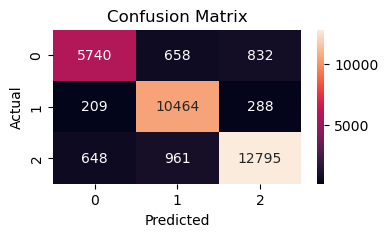

In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
# Heatmap
plt.figure(figsize=(4,2))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [18]:
import gradio as gr
# -------------------------------------------------------------
# Function to run all model predictions
# -------------------------------------------------------------
def analyze_sentiment(user_input):
    # Preprocess the input text
    cleaned_input = clean_text(user_input)
    # Vectorize the text
    vectorized_input = vectorizer.transform([cleaned_input])

    # Predictions from all models
    log_reg_pred = label_map_reverse[ model.predict(vectorized_input)[0] ]
    dt_pred      = label_map_reverse[ dt_model.predict(vectorized_input)[0] ]
    nb_pred      = label_map_reverse[ nb_model.predict(vectorized_input)[0] ]
    svm_pred     = label_map_reverse[ svm_model.predict(vectorized_input)[0] ]

    # Return each prediction separately (for individual textboxes)
    return log_reg_pred, dt_pred, nb_pred, svm_pred
# -------------------------------------------------------------
# Gradio Interface
# -------------------------------------------------------------
interface = gr.Interface(
    fn=analyze_sentiment,
    inputs=gr.Textbox(label="Enter your comment: ", placeholder="Type your text here..."),
    outputs=[
        gr.Textbox(label="Logistic Regression Output"),
        gr.Textbox(label="Decision Tree Output"),
        gr.Textbox(label="Naive Bayes Output"),
        gr.Textbox(label="SVM Output")
    ],
    title="Sentiment Analysis (Multiple Models)",
    description="This interface analyzes the Airline sentiment using 4 different machine learning models."
)
# Launch the GUI
interface.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
